# Observable-Based Circuit Simulation

The excitation transport in {doc}`analog_simulation` can also be simulated with
a quantum circuit. We use the same **20-site XY chain**, localized excitation,
and relaxation rates, then replace continuous Hamiltonian evolution with short
sequences of exchange gates. Sampling observables between these sequences lets
us reconstruct the occupation heatmaps and compare digital and analog dynamics.

The example uses the standard YAQS installation and public interfaces. Run the
cells in order in a notebook; in a script, use the entry-point guard in
{doc}`simulator_initialization`. For bitstring counts rather than expectation
values, see {doc}`circuit_shots`.

## 1. Turn the XY Hamiltonian into gates

The Hamiltonian exchanges excitations between neighboring sites,

$$
H=-\frac{1}{2}\sum_{i=0}^{L-2}(X_iX_{i+1}+Y_iY_{i+1}).
$$

As in the analog guide, we set the hopping amplitude to one and use $\hbar=1$.
An exchange gate on sites $i$ and $i+1$ implements their contribution to the
evolution. Qiskit's `XXPlusYYGate(-2 * duration)` gives
$\exp[+i\,\mathtt{duration}(XX+YY)/2]$, with the sign set by this Hamiltonian.

Gates on overlapping bonds do not commute. We approximate a time step with half
a step on even bonds, a full step on odd bonds, then another half step on even
bonds. This symmetric Trotter formula approaches the Hamiltonian dynamics as the
step decreases. Each exchange gate preserves excitation number, including when
noise acts between gates.

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import XXPlusYYGate


def xy_circuit(length, dt, steps):
    """Build a symmetric XY Trotter circuit and count gate exposures per step."""
    step_circuit = QuantumCircuit(length)
    gate_exposures = np.zeros(length, dtype=int)
    for parity, fraction in ((0, 0.5), (1, 1.0), (0, 0.5)):
        for site in range(parity, length - 1, 2):
            step_circuit.append(XXPlusYYGate(-2 * dt * fraction), [site, site + 1])
            gate_exposures[[site, site + 1]] += 1

    circuit = QuantumCircuit(length)
    for step in range(steps):
        circuit.compose(step_circuit, inplace=True)
        if step < steps - 1:
            circuit.barrier(label="SAMPLE_OBSERVABLES")
    return circuit, gate_exposures


length = 20
dt = 0.25
steps = 12
circuit, gate_exposures = xy_circuit(length, dt, steps)

The circuit represents evolution to $t=3$. Labelled barriers separate the
Trotter steps so YAQS can sample observables at the same 13 times as the analog
guide. `gate_exposures` counts each site's two-qubit gates in one step; we will
use these counts to match the relaxation rate.

## 2. Prepare the state and observables

Start with one excitation at site 10. Measuring $Z_i$ at every site gives the
occupation through $\langle n_i\rangle=(1-\langle Z_i\rangle)/2$.

In [2]:
from mqt.yaqs import DigitalSimParams, NoiseModel, Observable, Simulator, State

center = length // 2
basis = "0" * center + "1" + "0" * (length - center - 1)
state = State(length, initial="basis", basis_string=basis)
observables = [Observable("z", site) for site in range(length)]
params = DigitalSimParams(
    observables=observables,
    sample_layers=True,
    num_traj=16,
    preset="fast",
    random_seed=7,
)
sim = Simulator(show_progress=False)

`sample_layers=True` records observables at the circuit start, at each barrier
labelled `SAMPLE_OBSERVABLES`, and after the final gates. Barrier labels are
case-insensitive; unlabelled barriers do not trigger sampling. These checkpoints
evaluate expectations without collapsing the state, unlike hardware mid-circuit
measurements.

The noisy results average 16 trajectories, while a noiseless run uses one.
Parallel execution remains enabled. The documentation suppresses progress bars;
omit `show_progress=False` to see them. The preset controls numerical
tolerances, while `num_traj` controls sampling uncertainty.

## 3. Match relaxation to circuit steps

The analog model uses a uniform relaxation rate $\gamma$ per unit of physical
time. Circuit noise instead acts for one unit of noise time after each gate on
two or more qubits, using only processes supported on that gate's qubits.
Single-qubit gates and idle sites receive no noise.

Using the same numerical strength for every gate would make damping depend on
the number of gates rather than the represented duration. For a site involved in
$m_i$ gates per Trotter step, set its circuit strength to

$$
\mathtt{strength}_i=\frac{\gamma\,\Delta t}{m_i}.
$$

Here the end sites encounter two gates per step and interior sites encounter
three. Dividing by these counts gives each site a total relaxation exposure of
$\gamma\Delta t$ per step. Noise is still interleaved with the gates, so the
finite-step evolution can differ from the continuous analog model. This rate
mapping describes a digital approximation to that model; hardware gate noise
should instead follow the device and its compiled operations.

In [3]:
rates = [0.0, 0.5, 1.5, 4.0]
results = {}
for rate in rates:
    noise = None if rate == 0 else NoiseModel([
        {"name": "lowering", "sites": [site],
         "strength": rate * dt / gate_exposures[site]}
        for site in range(length)
    ])
    results[rate] = sim.run(state, circuit, params, noise)

## 4. Read the sampled dynamics

`expectation_values` contains one NumPy array per observable. The observable
order follows the supplied list, and each array follows checkpoint order.
Combine the arrays and convert $Z_i$ to occupation:

In [4]:
times = dt * np.arange(steps + 1)
occupations = np.stack([
    (1 - np.asarray(results[rate].expectation_values).real) / 2
    for rate in rates
])
print(occupations.shape)

(4, 20, 13)


The shape is `(4, 20, 13)`: relaxation rates by sites by checkpoints. Digital
results can store complex values; `.real` selects the real expectation of these
Hermitian observables. `result.trajectories` retains the per-trajectory data.

A standalone circuit has `result.times=None` because its gates do not define
physical durations. The `times` array above assigns physical times from our
Trotter construction. For final observables only, omit `sample_layers=True`;
each observable then has one sample. To collect counts too, supply `shots` and
YAQS distributes that total budget across the noisy observable trajectories.

## 5. Reconstruct the transport heatmaps

The following panels use the analog guide's time window, noise strengths, and
shared square-root color scale. They show absolute occupation, without
normalizing by the remaining excitation.

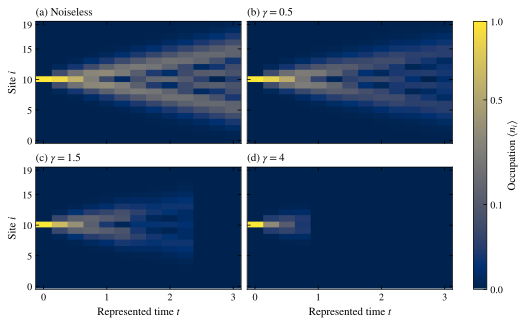

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.linewidth": 0.7,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "lines.linewidth": 1.6,
    "figure.constrained_layout.use": True,
    "savefig.dpi": 180,
})
fig, axes = plt.subplots(2, 2, figsize=(7.2, 4.4), sharex=True, sharey=True)
for ax, values, rate, panel in zip(axes.flat, occupations, rates, "abcd", strict=True):
    image = ax.pcolormesh(times, np.arange(length), values, shading="auto",
                          cmap="cividis", norm=PowerNorm(0.5, vmin=0, vmax=1),
                          rasterized=True)
    label = "Noiseless" if rate == 0 else rf"$\gamma={rate:g}$"
    ax.set_title(f"({panel}) {label}", loc="left", fontsize=11)
    ax.set(xticks=[0, 1, 2, 3], yticks=[0, 5, 10, 15, 19])
for ax in axes[-1]:
    ax.set_xlabel(r"Represented time $t$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"Site $i$")
fig.colorbar(image, ax=axes.ravel().tolist(),
             label=r"Occupation $\langle n_i\rangle$", ticks=[0, 0.1, 0.5, 1])
plt.show()

**Digital reconstruction of excitation transport and loss.** Exchange gates
spread the initial excitation along the chain, while increasing relaxation
suppresses occupation at later times. The broad patterns reproduce the analog
example, with differences from Trotter splitting and finite trajectory sampling.

The heatmaps alone do not tell us how close the circuit is to Hamiltonian
evolution. To separate the approximation in the gates from sampling noise, we
next compare the noiseless circuit with an analog reference and a finer circuit.

## 6. Compare with analog evolution

Run the same Hamiltonian without noise, then halve the circuit step while
keeping the total duration fixed. Select every second checkpoint of the finer
circuit to compare at the original sampling times.

In [6]:
from mqt.yaqs import AnalogSimParams, Hamiltonian

hamiltonian = Hamiltonian.heisenberg(length, Jx=0.5, Jy=0.5, Jz=0.0)
analog_params = AnalogSimParams(
    observables=observables, elapsed_time=steps * dt, dt=dt, preset="fast",
)
analog = sim.run(state, hamiltonian, analog_params)
analog_occupation = (1 - np.asarray(analog.expectation_values)) / 2

fine_circuit, _ = xy_circuit(length, dt / 2, steps * 2)
fine_result = sim.run(state, fine_circuit, params)
fine_occupation = (1 - np.asarray(fine_result.expectation_values).real[:, ::2]) / 2

The first panel compares final occupation profiles. The second sums occupation
over sites and compares noisy circuit estimates with the analog model's decay
law, $N(t)=e^{-\gamma t}$. This law holds because the initial state contains one
excitation, the Hamiltonian conserves excitation, and relaxation is uniform.

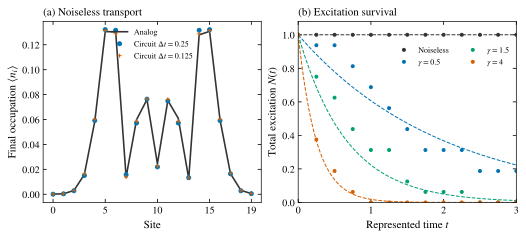

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))
ax = axes[0]
for values, label, style, color in (
    (analog_occupation, "Analog", "-", "0.2"),
    (occupations[0], r"Circuit $\Delta t=0.25$", "o", "#0072B2"),
    (fine_occupation, r"Circuit $\Delta t=0.125$", "+", "#D55E00"),
):
    ax.plot(np.arange(length), values[:, -1], style, color=color,
            label=label, markersize=4)
ax.set(xlabel="Site", ylabel=r"Final occupation $\langle n_i\rangle$",
       xticks=[0, 5, 10, 15, 19])
ax.set_title("(a) Noiseless transport", loc="left", fontsize=11)
ax.legend(loc="upper center", fontsize=8)

ax = axes[1]
colors = ["0.2", "#0072B2", "#009E73", "#D55E00"]
fine_times = np.linspace(0, times[-1], 200)
for rate, values, color in zip(rates, occupations, colors, strict=True):
    ax.plot(times, values.sum(axis=0), "o", color=color, markersize=3,
            label="Noiseless" if rate == 0 else rf"$\gamma={rate:g}$")
    ax.plot(fine_times, np.exp(-rate * fine_times), "--", color=color, linewidth=1)
ax.set(xlabel=r"Represented time $t$", ylabel=r"Total excitation $N(t)$",
       xlim=(0, 3), ylim=(0, 1.08), xticks=[0, 1, 2, 3])
ax.set_title("(b) Excitation survival", loc="left", fontsize=11)
ax.legend(ncols=2, loc="upper right", bbox_to_anchor=(1, 0.9), fontsize=8)
plt.show()

**Analog and digital transport compared at the same duration.** The final
noiseless profiles agree closely, and a smaller Trotter step reduces the
circuit's splitting error. Noisy survival estimates follow the uniform-loss
decay within the resolution of this 16-trajectory example; dashed lines show the
continuous-model reference.

This comparison connects the two workflows through their physical model, rather
than equating a circuit's gate count with elapsed time. Check Trotter-step
convergence separately from MPS tolerances and trajectory uncertainty. For noisy
refinement, rebuild the circuit and rescale the strengths using the new step and
gate exposures. Finite-step noise splitting can also affect the spatial profile;
agreement of total excitation alone does not validate that profile.

(circuit-qasm-inputs)=

## 7. OpenQASM inputs

Pass an OpenQASM 2 source string (or file path) directly to
{meth}`~mqt.yaqs.Simulator.run` instead of building a
{class}`qiskit.circuit.QuantumCircuit` in Python. Custom gate bodies declared in
the program are translated like any other Qiskit operation.

In [8]:
from mqt.yaqs import DigitalSimParams

qasm = """
OPENQASM 2.0;
include "qelib1.inc";

gate entangle a,b {
  h a;
  cx a,b;
}

qreg q[2];
entangle q[0], q[1];
"""

qasm_state = State(2, initial="zeros")
qasm_result = sim.run(
    qasm_state,
    qasm,
    DigitalSimParams(shots=128, max_bond_dim=4),
)

OpenQASM 3 requires `uv pip install mqt-yaqs[qasm3]`.
{class}`~mqt.yaqs.EquivalenceChecker` accepts the same path and string forms;
see {doc}`equivalence_checking`.

## 8. Gate application modes

`DigitalSimParams.gate_mode` selects how two-qubit gates are applied to the MPS.
The default `"mpo"` uses extended gate MPOs for long-range pairs; `"tdvp"` uses
a local TDVP window when an analytic generator is available. See
{doc}`simulation_parameters` for the available modes and
{ref}`circuit-custom-gates` for matrix-backed gates.

Below, a long-range `cx` on qubits 0 and 2 is simulated noiselessly with both
modes:

In [9]:
lr_qc = QuantumCircuit(3)
lr_qc.h(0)
lr_qc.cx(0, 2)

lr_state = State(3, initial="zeros")
z0_by_mode = {}
for mode in ("mpo", "tdvp"):
    mode_params = DigitalSimParams(
        observables=[Observable("z", 0)],
        num_traj=1,
        gate_mode=mode,
        max_bond_dim=8,
    )
    mode_result = sim.run(lr_state, lr_qc, mode_params)
    z0_by_mode[mode] = float(np.real(mode_result.expectation_values[0][0]))

print({mode: round(value, 4) for mode, value in z0_by_mode.items()})

{'mpo': 0.0, 'tdvp': 0.0}


(circuit-custom-gates)=

## 9. Supply custom gates

Add a custom unitary to a Qiskit circuit with `UnitaryGate`. YAQS translates the
matrix automatically, so no gate registration is needed. This two-qubit example
applies a phase only to the $|11\rangle$ component:

In [10]:
from qiskit.circuit.library import UnitaryGate

custom_unitary = np.diag([1, 1, 1, np.exp(0.4j)])
custom_circuit = QuantumCircuit(2)
custom_circuit.h([0, 1])
custom_circuit.append(UnitaryGate(custom_unitary), [0, 1])

custom_params = DigitalSimParams(observables=[Observable("x", 0)])
custom_sim = Simulator(show_progress=False)
custom_result = custom_sim.run(State(2, initial="zeros"), custom_circuit, custom_params)
print(custom_result.expectation_values[0])

[0.9605305+0.j]


The final expectation is $\langle X_0\rangle=(1+\cos 0.4)/2$, about 0.9605. The
matrix uses Qiskit's qubit ordering; YAQS converts it to its internal gate
layout. The same input works with `shots`, noise, and sampling checkpoints under
the circuit rules described above.

Custom gate bodies in {ref}`circuit-qasm-inputs` follow the same translation
path. Unknown unitary operations use a matrix fallback on up to eight qubits;
decompose larger operations first. A matrix-backed gate has no analytic
generator: TDVP gate modes use direct local updates for adjacent pairs and the
MPO path for separated sites or larger gates. Keep `gate_mode="mpo"` unless you
need another method.

:::{dropdown} Supported instructions and gate translation

Bind symbolic Qiskit parameters before simulation. YAQS translates known gate
names through its gate library; other operations must provide a unitary matrix
through Qiskit's `to_matrix()` or `Operator`. This also supports gates defined
by a reusable Qiskit circuit or an OpenQASM gate body. Use a distinct name for a
custom operation, since a name matching a built-in alias selects that built-in
implementation.

Terminal measurements are removed before simulation; request `shots` for
readout. Measurements followed by further operations on the measured qubits are
unsupported. `reset`, `delay`, `store`, classical conditions, and control-flow
instructions are also unsupported. Ordinary barriers do not change the state;
barriers labelled `SAMPLE_OBSERVABLES` mark sampling points.

Digital gates require qubit target sites. Idle sites can have other local
dimensions, but `gate_mode="swaps"` cannot route through a non-qubit site.

Built-in `ccx`, `ccz`, and `cswap` gates translate without decomposition.
Simulation applies gates on three or more qubits through an MPO, except
supported product generators such as `ccx` and `ccz` in TDVP modes. The
`"swaps"` mode also uses the MPO path for these larger gates.

`EquivalenceChecker` accepts the same unitary and OpenQASM inputs. Gates on more
than two qubits require its `"matrix"` backend; decompose them before using the
`"mpo"` backend. See {doc}`equivalence_checking` for backend choice and
measurement restrictions. Translation details and the supported alias list are
in {mod}`~mqt.yaqs.digital.utils.dag_utils`.

:::

:::{dropdown} Low-level gate objects

Application code should supply Qiskit circuits. For code that works directly
with YAQS gate kernels, `GateLibrary.custom` constructs a matrix-backed
{class}`~mqt.yaqs.core.libraries.gate_library.BaseGate`:

```python
from mqt.yaqs.core.libraries.gate_library import GateLibrary

gate = GateLibrary.custom(np.eye(4, dtype=complex))
gate.name = "my_gate"
gate.set_sites(0, 1)
```

This constructor checks that the matrix is square with dimension $2^n$. The
caller must supply a finite unitary. The resulting fields are:

| Field         | Meaning                                                        |
| ------------- | -------------------------------------------------------------- |
| `matrix`      | Gate matrix in YAQS gate order.                                |
| `interaction` | Number of target qubits, inferred from the matrix size.        |
| `sites`       | Target sites in their declared order.                          |
| `tensor`      | Gate tensor; `set_sites` reshapes gates on two or more qubits. |
| `generator`   | Optional local factors for a product-form TDVP generator.      |
| `name`        | Gate identifier.                                               |

In a manually supplied gate matrix, the first tensor factor acts on the first
declared site. Qiskit translation handles its different matrix convention
automatically. Creating this object does not register a new Qiskit gate or make
it a valid operator argument to `Simulator.run`.

Built-in gates subclass `BaseGate` and prepare tensors and optional generators
in `set_sites`. See {class}`~mqt.yaqs.core.libraries.gate_library.CX` and
{class}`~mqt.yaqs.core.libraries.gate_library.CCX` for examples.

:::

:::{dropdown} Product generators for digital TDVP

A TDVP-capable gate has one $2\times2$ generator factor per target site. The
factors define a product $G$ whose exponential at evolution time one must
reproduce the gate, $U=\exp(-iG)$. For example, a ZZ phase rotation has
$G=(\theta Z/2)\otimes Z$:

```python
from scipy.linalg import expm

from mqt.yaqs.core.libraries.gate_library import GateLibrary

theta = 0.3
pauli_z = np.diag([1.0, -1.0])
generator_factors = [theta * pauli_z / 2, pauli_z]
phase_unitary = expm(-1j * np.kron(*generator_factors))
phase_gate = GateLibrary.custom(phase_unitary)
phase_gate.set_sites(0, 2)
phase_gate.generator = generator_factors
```

The factors follow the declared `sites` order. YAQS places identities between
separated factors when constructing the generator MPO. The caller must check
that the full generator is Hermitian and reproduces the unitary; YAQS does not
verify that relation. This low-level assignment does not change how a Qiskit
`UnitaryGate` is translated.

Digital generator evolution requires `tdvp_mode="2site"`. `tdvp_sweeps` divides
the total generator time of one into substeps. TDVP gate application remains
approximate and can miss required bond growth; see {doc}`simulation_parameters`
for accuracy limits. Single-qubit gates always use direct contraction. For
implementation details, see
{func}`~mqt.yaqs.digital.digital_tjm.construct_generator_mpo`.

:::

## Related topics

- {doc}`digital_analog_simulation` — combine digital operations with analog
  evolution in one program
- {doc}`circuit_shots` — computational-basis shot histograms with
  {class}`~mqt.yaqs.DigitalSimParams`
- {doc}`realistic_noise_models` — log-normal and other distributed noise
  strengths
- {doc}`equivalence_checking` — verify that two circuits implement the same
  unitary
- {doc}`quickstart` — minimal analog, circuit, and equivalence-check workflows